# Task 3.4

1. Считать `image.jpg` с помощью OpenCV.
2. Преобразовать изображение в палитру RGB.
3. Применить `cv2.GaussianBlur()` с размером ядра `(9, 9)`.
4. Получить изображение с деталями как разность исходного и размытого изображения.
5. Сравнить результат с предложенными вариантами и указать идентификатор.

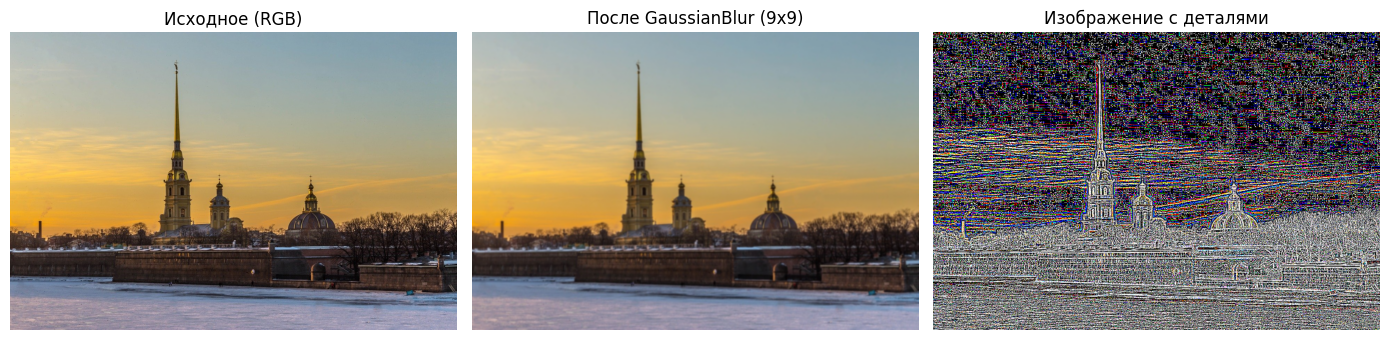

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg")
if image is None:
    raise FileNotFoundError("Не удалось открыть image.jpg")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
blurred = cv2.GaussianBlur(image_rgb, (9, 9), 0)

# Извлекаем детали как в референсе: uint8-разность без насыщения.
details = image_rgb - blurred

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Исходное (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred)
plt.title("После GaussianBlur (9x9)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(details)
plt.title("Изображение с деталями")
plt.axis("off")
plt.tight_layout()
plt.show()

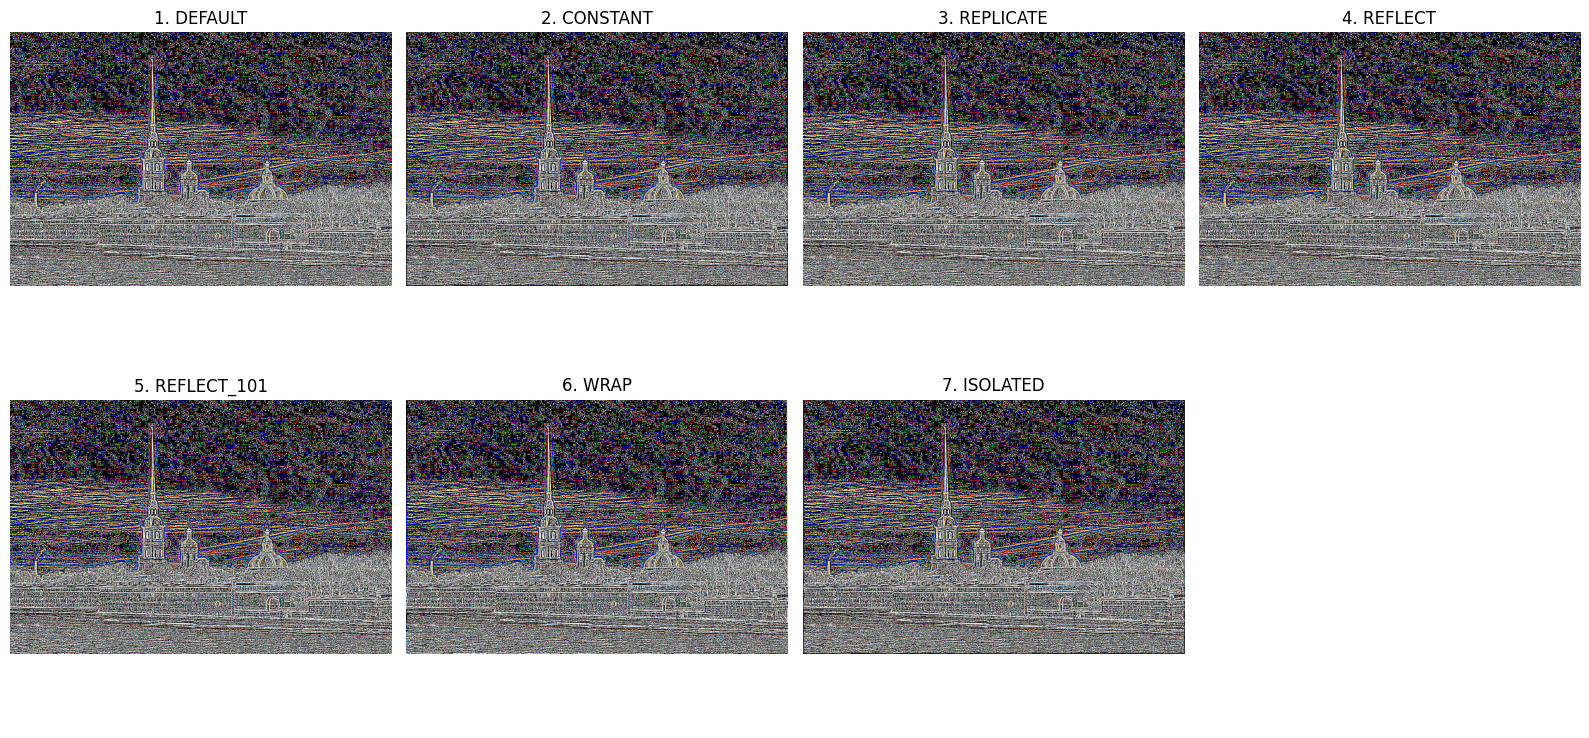

In [2]:
# Вспомогательная проверка: иногда варианты в тесте отличаются borderType.
# Эта ячейка покажет кандидатов, чтобы можно было быстро сопоставить с миниатюрами из задания.
border_types = [
    ("DEFAULT", cv2.BORDER_DEFAULT),
    ("CONSTANT", cv2.BORDER_CONSTANT),
    ("REPLICATE", cv2.BORDER_REPLICATE),
    ("REFLECT", cv2.BORDER_REFLECT),
    ("REFLECT_101", cv2.BORDER_REFLECT_101),
    ("WRAP", cv2.BORDER_WRAP),
    ("ISOLATED", cv2.BORDER_ISOLATED),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, (name, btype) in enumerate(border_types):
    b = cv2.GaussianBlur(image_rgb, (9, 9), 0, borderType=btype)
    d = image_rgb - b
    axes[i].imshow(d)
    axes[i].set_title(f"{i+1}. {name}")
    axes[i].axis("off")

for j in range(len(border_types), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()